In [1]:
import os
import time
import math
import pickle
from contextlib import nullcontext
import tiktoken
import torchsummary
import numpy as np
import torch
import pickle

from model.models import GPT
from model.config import TransformerConfig
from datasets import load_dataset

torch.manual_seed(42)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # To prevent the kernel from dying.
device = torch.device(
    "cuda:0" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print('You are using the following device: ', device)

torch.set_float32_matmul_precision('high')
# The flag below controls whether to allow TF32 on matmul. This flag defaults to False
# in PyTorch 1.12 and later.
import os
import time
import math
import pickle
from contextlib import nullcontext
import tiktoken
import torchsummary
import numpy as np
import torch
import pickle

from model.models import GPT
from model.config import TransformerConfig
from datasets import load_dataset

torch.manual_seed(42)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # To prevent the kernel from dying.
device = torch.device(
    "cuda:0" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print('You are using the following device: ', device)

# torch.set_float32_matmul_precision('high')
# # The flag below controls whether to allow TF32 on matmul. This flag defaults to False
# # in PyTorch 1.12 and later.
# torch.backends.cuda.matmul.allow_tf32 = True
#
# # The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
# torch.backends.cudnn.allow_tf32 = True

C:\Users\Bekir\PycharmProjects\ScratchTransformer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


You are using the following device:  cuda:0
You are using the following device:  cuda:0


C:\Users\Bekir\PycharmProjects\ScratchTransformer\.venv\Lib\site-packages\torch\__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


In [2]:
# Disabled for now - use test_dataset.pickle, which contains the first 256 samples
# dataset = load_dataset("PleIAs/SYNTH", split="train")
dataset = pickle.load(open('test_dataset.pickle', 'rb'))

In [3]:
# Initialize tokenizer
enc = tiktoken.get_encoding("gpt2")
print(f"Vocabulary size: {enc.n_vocab}")


Vocabulary size: 50257


In [4]:
# Prepare and tokenize the dataset
def prepare_data(dataset, tokenizer, sequence_length=512):
    """
    Combines query, synthetic_reasoning, and synthetic_answer columns,
    tokenizes them, and creates input-target pairs for language modeling.
    """
    all_tokens = []
    
    # Dataset is a dict with keys as column names and values as lists
    num_examples = len(dataset['query'])
    
    for i in range(num_examples):
        # Combine the three text columns with separator tokens
        combined_text = (
            dataset['query'][i] + '\n\n' + 
            dataset['synthetic_reasoning'][i] + '\n\n' + 
            dataset['synthetic_answer'][i]
        )
        
        # Tokenize
        tokens = tokenizer.encode(combined_text, allowed_special={'<|endoftext|>'})
        all_tokens.extend(tokens)
        all_tokens.append(tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0])  # Add EOS token
    
    # Create sequences of fixed length
    input_ids = []
    target_ids = []
    
    for i in range(0, len(all_tokens) - sequence_length, sequence_length):
        chunk = all_tokens[i:i + sequence_length + 1]
        if len(chunk) == sequence_length + 1:
            input_ids.append(chunk[:-1])
            target_ids.append(chunk[1:])
    
    return torch.tensor(input_ids, dtype=torch.long), torch.tensor(target_ids, dtype=torch.long)

# Process the dataset
print("Processing and tokenizing dataset...")
input_ids, target_ids = prepare_data(dataset, enc, sequence_length=512)
print(f"Created {len(input_ids)} training sequences")
print(f"Input shape: {input_ids.shape}")
print(f"Target shape: {target_ids.shape}")


Processing and tokenizing dataset...
Created 421 training sequences
Input shape: torch.Size([421, 512])
Target shape: torch.Size([421, 512])


In [5]:
# Create DataLoader
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(input_ids, target_ids)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Created DataLoader with {len(train_dataloader)} batches")


Created DataLoader with 27 batches


In [6]:
config = TransformerConfig(
    embedding_dim=768,
    num_attention_heads=12,
    attention_dim=64,
    block_num=6,
    sequence_length=512,
    vocab_size=enc.n_vocab,
    feed_forward_dim=2048,
    flash_attention=False,
)

In [7]:
model = GPT(config)
model = torch.compile(model, backend="cudagraphs")
model = model.to(device)

In [8]:
# list = []
# list.append([512])
# torchsummary.summary(model, list)

In [9]:
# Training setup
learning_rate = 3e-4
max_epochs = 10
grad_clip = 1.0

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)

print(f"Training for {max_epochs} epochs")
print(f"Learning rate: {learning_rate}")
print(f"Batches per epoch: {len(train_dataloader)}")


Training for 10 epochs
Learning rate: 0.0003
Batches per epoch: 27


In [10]:
# Training loop
model.train()
losses = []

for epoch in range(max_epochs):
    epoch_loss = 0.0
    epoch_start = time.time()
    
    for batch_idx, (inputs, targets) in enumerate(train_dataloader):
        # Move data to device
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        logits, loss = model(inputs, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        # Update weights
        optimizer.step()
        
        # Track loss
        epoch_loss += loss.item()
        
        # Print progress
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{max_epochs} | Batch {batch_idx}/{len(train_dataloader)} | Loss: {loss.item():.4f}")
    
    # Epoch summary
    avg_loss = epoch_loss / len(train_dataloader)
    losses.append(avg_loss)
    epoch_time = time.time() - epoch_start
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{max_epochs} completed in {epoch_time:.2f}s")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"{'='*60}\n")

print("Training completed!")


C:\Users\Bekir\PycharmProjects\ScratchTransformer\.venv\Lib\site-packages\torch\_dynamo\guards.py:1114: RuntimeWarning: Guards may run slower on Python 3.13.0. Consider upgrading to Python 3.13.1+.
  warnings.warn(


Epoch 1/10 | Batch 0/27 | Loss: 10.9160
Epoch 1/10 | Batch 10/27 | Loss: 8.3629
Epoch 1/10 | Batch 20/27 | Loss: 7.8232


E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1] Error while creating guard:
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1] Name: ''
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Source: shape_env
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Create Function: SHAPE_ENV
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Guard Types: ['SHAPE_ENV', 'SHAPE_ENV']
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Code List: ["L['targets'].size()[0] == L['x'].size()[0]", "2 <= L['x'].size()[0]"]
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Object Weakref: None
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1]     Guarded Class Weakref: None
E1123 18:24:28.800000 20544 .venv\Lib\site-packages\torch\_guards.py:368] [0/1] Tr

InternalTorchDynamoError: RuntimeError: Compiler: cl is not found.


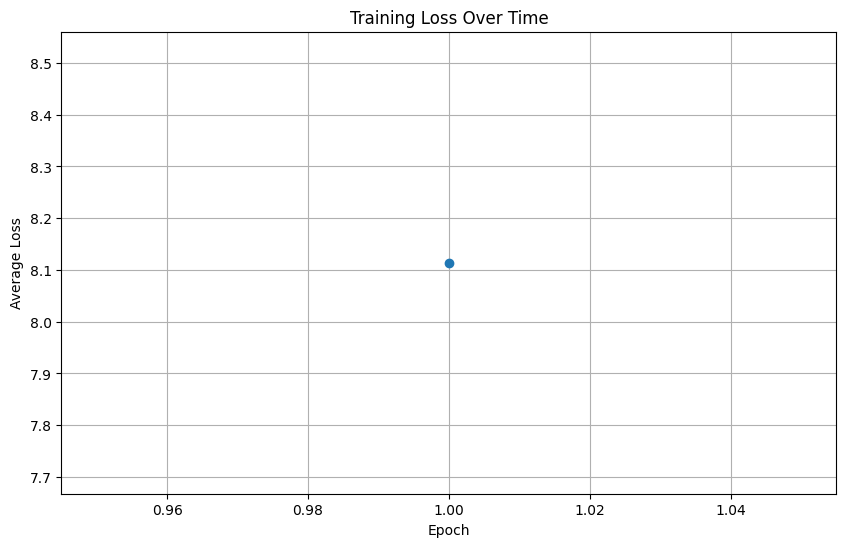

In [11]:
# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()


In [12]:
# Test generation
@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=100, temperature=0.8, top_k=50):
    model.eval()
    
    # Tokenize prompt
    tokens = enc.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    # Generate
    for _ in range(max_new_tokens):
        # Crop context if needed
        tokens_cond = tokens if tokens.size(1) <= config.sequence_length else tokens[:, -config.sequence_length:]
        
        # Forward pass
        logits, _ = model(tokens_cond)
        logits = logits[:, -1, :] / temperature
        
        # Top-k sampling
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')
        
        # Sample
        probs = torch.nn.functional.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        
        # Append to sequence
        tokens = torch.cat([tokens, next_token], dim=1)
    
    # Decode
    generated_text = enc.decode(tokens[0].tolist())
    return generated_text

# Test the model
prompt = "What is the capital of France"
print(f"Prompt: {prompt}")
print(f"\nGenerated text:\n{generate_text(model, prompt, max_new_tokens=50)}")


Prompt: What is the capital of France


E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2] Error while creating guard:
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2] Name: ''
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Source: shape_env
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Create Function: SHAPE_ENV
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Guard Types: ['SHAPE_ENV', 'SHAPE_ENV', 'SHAPE_ENV']
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Code List: ["L['x'].stride()[0] == L['x'].size()[1]", "L['x'].size()[1] != 512", "2 <= L['x'].size()[1] and L['x'].size()[1] <= 512"]
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Object Weakref: None
E1123 18:20:30.821000 21460 .venv\Lib\site-packages\torch\_guards.py:368] [0/2]     Guarded Class Weakref: None
E1123 18:20:30.821

InternalTorchDynamoError: RuntimeError: Compiler: cl is not found.
